# Sentimental Analysis for IMDB 

### Objective

Develop a sentiment analysis system using a Recurrent Neural Network (RNN) that reads IMDb movie reviews and classifies them as:

* Positive 😊
* Negative 😞

The model learns the sequential relationship between words in a review and predicts its sentiment.

### Dataset 
Use the IMDb Movie Reviews dataset, where each review has a sentiment label:

* 1 → Positive
* 0 → Negative

A common version contains 50,000 reviews.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
num_words = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=num_words
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


### Insight:
The IMDb dataset contains movie reviews labeled as positive or negative. The dataset is divided into training and testing data, with 25,000 reviews used for training and 25,000 reviews used for testing. This dataset is suitable for building a binary sentiment classification model.

### Padding

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


### Insight:
The reviews were converted into numerical sequences so that they could be processed by the neural network. Padding was applied to make all reviews the same length of 200. This provides a fixed-size input for the RNN model.

### RNN Model

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_shape=(200,)),
    SimpleRNN(64),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\LAPZONE\.ipython\Lib\site-packages\keras\src\layers\core\embedding.py:126: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

### Insight:
A Recurrent Neural Network was used because it can process sequential data such as text. The Embedding layer represents words numerically, while the SimpleRNN layer learns relationships between words in the review. The final Dense layer with sigmoid activation performs positive or negative classification.

### Model Trianing

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.6841 - loss: 0.5790 - val_accuracy: 0.7250 - val_loss: 0.5646
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7999 - loss: 0.4340 - val_accuracy: 0.8114 - val_loss: 0.4314
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.8975 - loss: 0.2525 - val_accuracy: 0.8122 - val_loss: 0.4460
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9660 - loss: 0.1015 - val_accuracy: 0.8198 - val_loss: 0.5596
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.9907 - loss: 0.0342 - val_accuracy: 0.7916 - val_loss: 0.7024


### Insight: 
The training accuracy increased to 99.07%, while the validation accuracy reached 79.16%. This shows that the RNN learned the training data very well. However, the lower validation accuracy indicates that the model may have some overfitting and does not generalize equally well to unseen data.

### Trainig & Validation Accuracy Graph

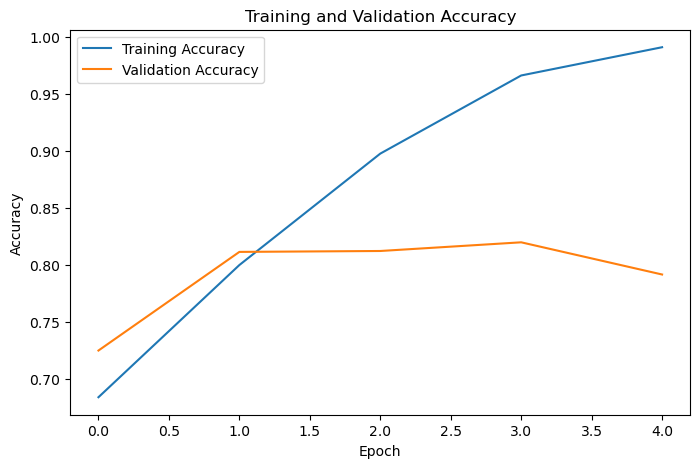

In [6]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Insight:
The training accuracy increases across the epochs, showing that the model is learning from the training data. The validation accuracy improves initially but does not continue to increase at the same rate. This difference suggests that the model may not generalize equally well to unseen review

### Loss Graph

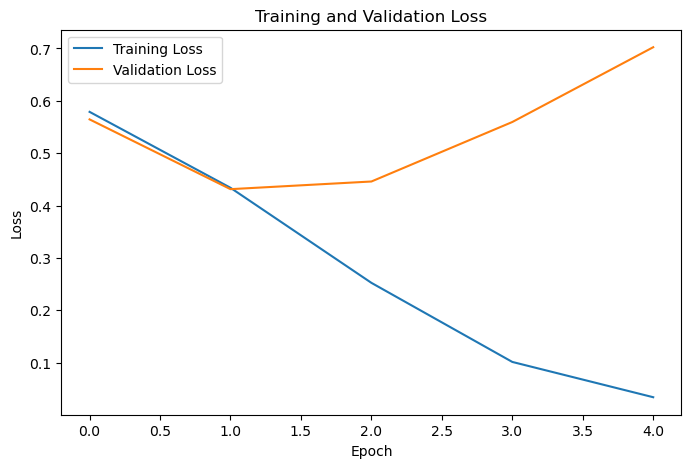

In [7]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Insight:
The training loss decreases as the number of epochs increases, indicating that the model is learning effectively from the training data. However, the validation loss does not decrease consistently. This further indicates possible overfitting in the model.

### Model Evaluation

In [8]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step


### Prediction

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.78948
Precision: 0.7921679450948729
Recall   : 0.78488
F1 Score : 0.7885071328109303


### Insight:
The trained RNN model generated predictions for the IMDb test dataset. The predicted probabilities were converted into binary sentiment classes using a threshold of 0.5, where 0 represents negative sentiment and 1 represents positive sentiment. These predictions were then used to evaluate the model using standard classification metrics.

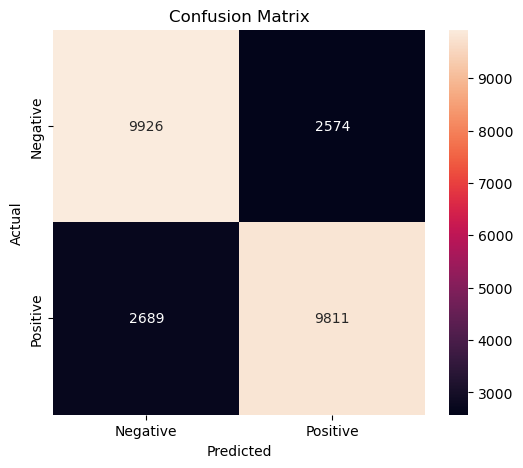

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Insight:
The confusion matrix shows the correctly and incorrectly classified positive and negative reviews. It helps identify true positives, true negatives, false positives, and false negatives.

### Classification Report

In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.79      0.79      0.79     12500
    Positive       0.79      0.78      0.79     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000



### Insight:
The classification report provides precision, recall, and F1-score for both positive and negative classes. It gives a detailed view of how well the model performs for each sentiment category.

### Testing New Review

In [17]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load IMDb word index
word_index = imdb.get_word_index()

def encode_review(review):
    words = review.lower().split()

    encoded = [1]   # Start token

    for word in words:
        index = word_index.get(word, 2) + 3

        # Keep only words within our 10,000-word vocabulary
        if index < 10000:
            encoded.append(index)
        else:
            encoded.append(2)

    return encoded

# New review
review = "I absolutely loved this movie. It was fantastic, excellent, wonderful and amazing."

# Convert review to numbers
encoded_review = encode_review(review)

# Padding
padded_review = pad_sequences(
    [encoded_review],
    maxlen=200
)

# Prediction
prediction = model.predict(padded_review, verbose=0)

score = prediction[0][0]

print("Review:", review)
print("Prediction Score:", score)

if score >= 0.5:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

Review: I absolutely loved this movie. It was fantastic, excellent, wonderful and amazing.
Prediction Score: 0.99715954
Sentiment: Positive 😊


### Insight:
The trained RNN model was tested with a new movie review that was not directly used during training. The review was converted into the required numerical format and given to the model. The model then predicted the sentiment as positive or negative.

In [13]:
y_pred_prob = model.predict(X_test, verbose=0)

y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")

Predictions generated successfully!


### Conclusion
The RNN-based sentiment analysis system was successfully developed using IMDb movie reviews. The model learned sequential patterns in the review text and classified reviews into positive and negative sentiments. Training and validation performance were analyzed using accuracy and loss graphs. The model was further evaluated using standard classification metrics, confusion matrix, and classification report. Finally, a new movie review was given to the trained model to demonstrate real-world sentiment prediction.